In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("stealthtechnologies/rock-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 213M/213M [00:02<00:00, 98.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/stealthtechnologies/rock-classification/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/stealthtechnologies/rock-classification/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/stealthtechnologies/rock-classification/versions/1):
['Rock Data']


In [ ]:
import os

# Update path to match 'Rock Data' directory
rock_data_path = os.path.join(path, 'Rock Data')

# List subdirectories in Rock Data (usually class labels)
if os.path.exists(rock_data_path):
    print(f"Classes in dataset: {os.listdir(rock_data_path)}")
else:
    print(f"Directory not found: {rock_data_path}")

Classes in dataset: ['train', 'valid', 'test', 'README.dataset.txt', 'README.roboflow.txt']



--- Sample Images from Dataset (/root/.cache/kagglehub/datasets/stealthtechnologies/rock-classification/versions/1/Rock Data) ---
Found 4212 images. Displaying 6 samples:


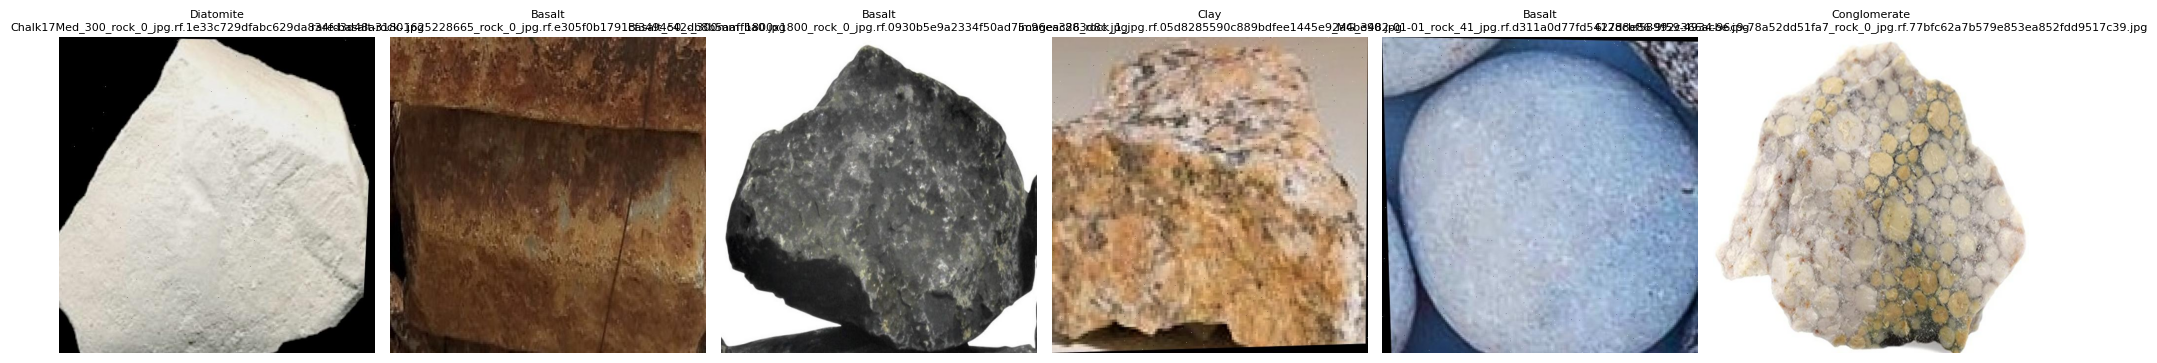

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} samples:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Display class name (parent directory) and filename
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the defined Rock Data path
rock_data_path = os.path.join(path, 'Rock Data')
print(f"\n--- Sample Images from Dataset ({rock_data_path}) ---")
display_sample_images(rock_data_path)

In [ ]:
# Check GPU availability
!nvidia-smi
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Sun Jul 26 14:58:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Define paths
train_dir = os.path.join(rock_data_path, 'train')
val_dir = os.path.join(rock_data_path, 'valid')

# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

# Number of classes
num_classes = len(train_ds.class_names)

# Build MobileNetV2 Model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze the base model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Found 3687 files belonging to 9 classes.
Found 351 files belonging to 9 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Train the model
EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 55s 311ms/step - accuracy: 0.2604 - loss: 2.0007 - val_accuracy: 0.2934 - val_loss: 1.9001
Epoch 2/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.3865 - loss: 1.7234 - val_accuracy: 0.3476 - val_loss: 1.7878
Epoch 3/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.4424 - loss: 1.5893 - val_accuracy: 0.3533 - val_loss: 1.7601
Epoch 4/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.4768 - loss: 1.4998 - val_accuracy: 0.3732 - val_loss: 1.7360
Epoch 5/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.4993 - loss: 1.4292 - val_accuracy: 0.3675 - val_loss: 1.7405
Epoch 6/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.5281 - loss: 1.3819 - val_accuracy: 0.3618 - val_loss: 1.7775
Epoch 7/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.5446 - loss: 1.3298 - val_accuracy: 0.3846 - val_loss: 1.7282
Epoch 8/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 0.5693 - loss: 1.2818 - val_a

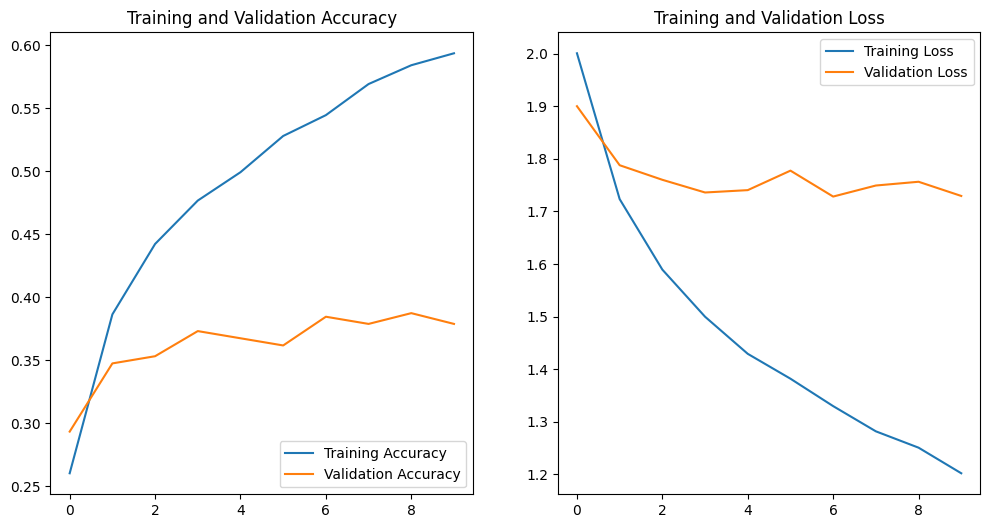

Training finished. Final Accuracy: 0.5937, Final Validation Accuracy: 0.3789


In [ ]:
# Summary and Plotting
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.show()

final_acc = acc[-1]
final_val_acc = val_acc[-1]
print(f"Training finished. Final Accuracy: {final_acc:.4f}, Final Validation Accuracy: {final_val_acc:.4f}")